In [43]:
import matplotlib.pyplot as plt
import numpy as np 


from scipy import stats

In [11]:
'''Country

Literacy

Literacy change

Numeracy

Numeracy change

Adaptive problem solving
'''

ss = '''Finland

296
15.20
294
16.70
276
Japan

289
-5.50
291
4.10
276
Sweden

284
4.90
285
6.20
273
Norway

281
4.40
285
8.30
271
Netherlands

279
-1.70
284
7.40
265
Estonia

276
0.90
281
9.30
263
Flemish Region (BE)

275
3.00
279
2.60
262
Denmark

273
8.80
279
7.70
264
England (UK)

272
-0.50
268
7.00
259
Canada

271
-0.50
271
6.70
259
Switzerland

266
276
257
Germany

266
0.00
273
4.80
261
Ireland

263
-3.30
260
4.70
249
Czechia

260
-8.80
267
-2.60
250
New Zealand

260
-21.10
256
-15.40
249
United States

258
-12.40
249
-7.30
247
France

255
-6.70
257
3.00
248
Austria

254
-11.90
267
-4.80
253
Singapore

254
-3.10
274
16.70
252
Croatia

254
254
235
Slovak Republic

254
-19.50
261
-14.70
247
Korea

249
-23.00
253
-10.00
238
Hungary

248
-14.60
254
-16.80
241
Latvia

248
263
244
Spain

247
-2.80
250
5.90
241
Italy

245
-4.80
244
-2.60
231
Israel

244
-10.30
246
-4.30
236
Lithuania

238
-28.40
246
-21.50
230
Poland*

236
-31.20
239
-21.00
226
Portugal

235
238
233
Chile

218
-2.20
214
8.30
218
'''

In [24]:
import string

In [39]:
data = [_ for _ in ss.split('\n') ]

dd = []

for _ in data:
    if not _ :continue
    if _[0] in string.ascii_uppercase:
        dd.append([_])
    else:
        val = float(_)
        if val > 200:
            dd[-1].append(val)

In [46]:
country, numeracy, literacy, problems = list( zip(* dd))

In [60]:
series = {"numeracy" : np.array(numeracy),
"literacy" : np.array(literacy),
"problems" : np.array(problems)
}



array([205.13432207, 302.47393332])

In [117]:
l

NameError: name 'xdf' is not defined

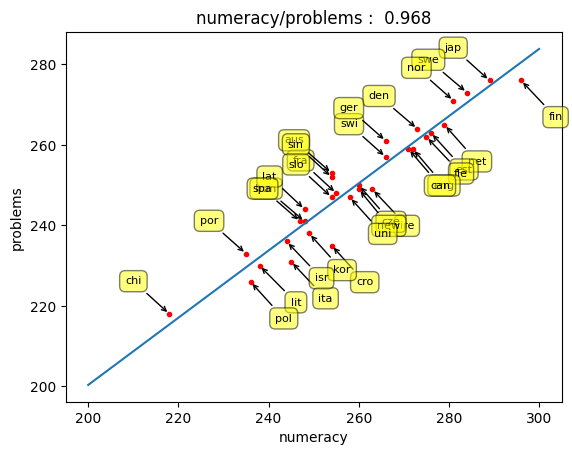

In [116]:
a,b = "numeracy","literacy"
a,b = "numeracy","problems"
#a,b = "literacy","problems"

vv = stats.linregress(series[a],series[b])
X = np.array([200,300])
vv.slope*X + vv.intercept

plt.plot(series[a],series[b],'r.');

plt.plot(X,vv.slope*X + vv.intercept);

mask = series[b] > (vv.slope*series[a] + vv.intercept)

for label, x, y, tt in zip(country, series[a], series[b], mask):
    offset = (-20, 20) if  tt else (30, -30)
    plt.annotate(
        label[:3].lower(),
        xy=(x, y), xytext=offset, fontsize= 8,
        textcoords='offset points', ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
        arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))

plt.title(f"{a}/{b} : {vv.rvalue: .3f}")
plt.xlabel(a);
plt.ylabel(b);

In [93]:
pred = vv.slope*series[a] + vv.intercept

mask = abs(series[b] - pred) > 4
mask = (series[b] - series[a]) < -3
[y for x,y in zip(mask,country) if x]

for x,y in zip(mask, dd):
    if not x: continue
    print(y)

['England (UK)', 272.0, 268.0, 259.0]
['New Zealand', 260.0, 256.0, 249.0]
['United States', 258.0, 249.0, 247.0]
['Chile', 218.0, 214.0, 218.0]


In [80]:
max(abs(series[b] - (vv.slope*series[a] + vv.intercept)))

16.30228785708266